In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import xgboost as xgb

## Dataset

We use the **California Housing** dataset from scikit-learn. Each row is a census block group in California. The target is the median house value (in $100k). It is a clean, well-known regression benchmark with enough observations to make the patterns visible.

| Feature | Description |
|---|---|
| MedInc | Median household income ($10k) |
| HouseAge | Median house age |
| AveRooms | Average rooms per household |
| AveBedrms | Average bedrooms per household |
| Population | Block population |
| AveOccup | Average household occupancy |
| Latitude | Block latitude |
| Longitude | Block longitude |

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

20,640 rows, 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Linear Regression: the assumptions you are always making

Ordinary least squares comes with five classical assumptions. Violating them does not always crash the model, but it means your coefficients, standard errors, and any inference you draw from them are unreliable.

| Assumption | What it requires |
|---|---|
| **Linearity** | The relationship between features and target is linear |
| **Homoscedasticity** | The variance of residuals is constant across all fitted values |
| **Normality of residuals** | Residuals follow a normal distribution |
| **Independence** | Observations are not correlated with each other |
| **No multicollinearity** | Features are not strongly correlated with each other |

Let us check the first three on this dataset using a single feature — median income vs house value. This is the clearest single-feature relationship in the data.

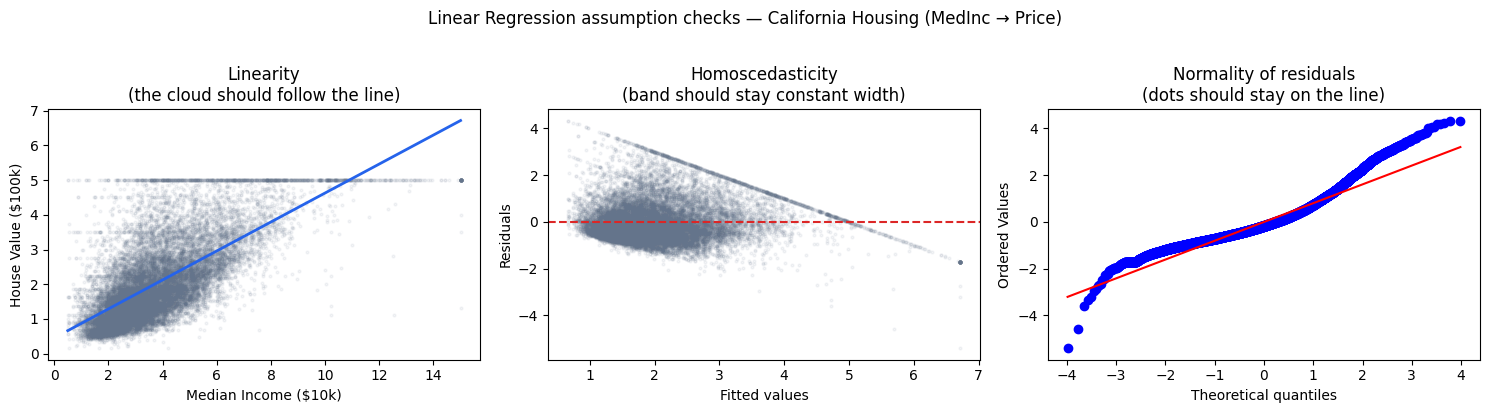

In [3]:
FEATURE = "MedInc"
TARGET = "MedHouseVal"

X_single = df[[FEATURE]]
y = df[TARGET]

lr = LinearRegression().fit(X_single, y)
fitted = lr.predict(X_single)
residuals = y - fitted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Scatter + fit line — linearity check
axes[0].scatter(df[FEATURE], y, alpha=0.07, s=4, color="#64748b")
x_line = np.linspace(df[FEATURE].min(), df[FEATURE].max(), 200)
axes[0].plot(x_line, lr.predict(x_line.reshape(-1, 1)), color="#2563eb", linewidth=2)
axes[0].set_xlabel("Median Income ($10k)")
axes[0].set_ylabel("House Value ($100k)")
axes[0].set_title("Linearity\n(the cloud should follow the line)")

# 2. Residuals vs fitted — homoscedasticity check
axes[1].scatter(fitted, residuals, alpha=0.07, s=4, color="#64748b")
axes[1].axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Homoscedasticity\n(band should stay constant width)")

# 3. QQ plot — normality of residuals check
stats.probplot(residuals, plot=axes[2])
axes[2].set_title("Normality of residuals\n(dots should stay on the line)")

plt.suptitle("Linear Regression assumption checks — California Housing (MedInc → Price)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("img/lr_assumptions.png", dpi=150, bbox_inches="tight")
plt.show()

All three assumptions are violated:

- **Linearity**: the scatter fans out above the fit line at high incomes, and there is a hard ceiling in the data around 5 ($500k) that a line cannot capture.
- **Homoscedasticity**: the residual band gets wider as fitted values increase — classic heteroscedasticity.
- **Normality**: the QQ plot shows heavy tails, especially at the upper end.

And this is just one feature on a well-behaved public dataset. In production, with dozens of features and real-world noise, checking all five assumptions properly before shipping a model is rarely feasible.

## 2. XGBoost does not care about any of this

Gradient boosting builds an ensemble of decision trees. Each tree splits the feature space into regions and assigns a constant prediction to each. The final prediction is the sum of all trees. There are no distributional assumptions, no linearity requirement, and no concept of residual normality.

On the same single-feature problem, let us compare cross-validated R² for both models.

In [4]:
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0)

lr_scores = cross_val_score(lr, X_single, y, cv=5, scoring="r2")
xgb_scores = cross_val_score(xgb_model, X_single, y, cv=5, scoring="r2")

print(f"Linear Regression — R²: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"XGBoost           — R²: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")

Linear Regression — R²: 0.421 ± 0.084
XGBoost           — R²: 0.434 ± 0.088


XGBoost explains meaningfully more variance on the same data with the same single feature, without any preprocessing or tuning. It naturally captures the non-linearity and the ceiling effect that the linear model cannot.

---

## 3. The catch: XGBoost cannot extrapolate

Here is the part that is easy to overlook.
* I overlooked several times before noticing!!

Each decision tree in XGBoost splits the feature space at thresholds it observed during training. For any input value above the training maximum, every tree falls into its rightmost leaf — the one covering the highest values seen. The prediction stays constant. It does not go up. It does not go down. It flatlines.

To make this concrete: we train both models only on houses where `MedInc ≤ 6` (roughly the lower 85% of the distribution). Then we ask both models to predict for income values all the way up to 15 — well beyond what they trained on.

Training samples: 18,278 / 20,640 (89%)
MedInc range in training: 0.50 – 6.00


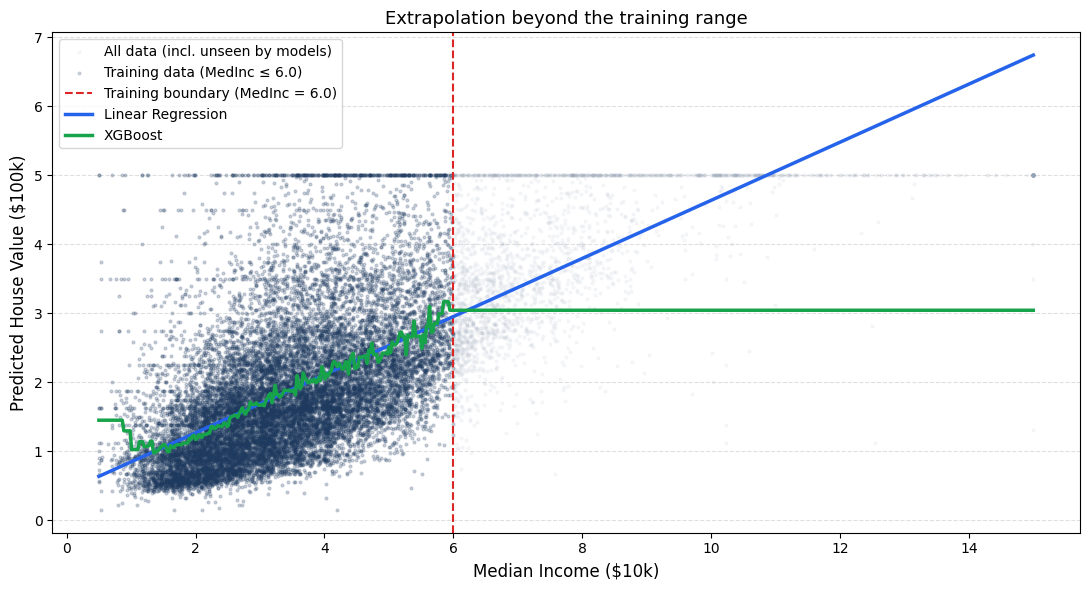


Predictions at different MedInc values:
  MedInc |    XGBoost |  Lin. Reg.
----------------------------------
     5.0 |      2.511 |      2.532
     6.0 |      3.044 |      2.953  ← training boundary
     7.0 |      3.044 |      3.374
     8.0 |      3.044 |      3.795
    10.0 |      3.044 |      4.637
    12.0 |      3.044 |      5.479
    15.0 |      3.044 |      6.743


In [5]:
TRAINING_CAP = 6.0

mask_train = df[FEATURE] <= TRAINING_CAP
X_train = df.loc[mask_train, [FEATURE]]
y_train = df.loc[mask_train, TARGET]

print(f"Training samples: {mask_train.sum():,} / {len(df):,} ({mask_train.mean():.0%})")
print(f"MedInc range in training: {X_train[FEATURE].min():.2f} – {X_train[FEATURE].max():.2f}")

lr_cap = LinearRegression().fit(X_train, y_train)
xgb_cap = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0).fit(X_train, y_train)

x_range = np.linspace(0.5, 15, 600).reshape(-1, 1)
pred_lr = lr_cap.predict(x_range)
pred_xgb = xgb_cap.predict(x_range)

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(df[FEATURE], df[TARGET], alpha=0.07, s=4, color="#94a3b8", label="All data (incl. unseen by models)")
ax.scatter(X_train, y_train, alpha=0.18, s=4, color="#1e3a5f", label=f"Training data (MedInc ≤ {TRAINING_CAP})")

ax.axvline(TRAINING_CAP, color="#dc2626", linestyle="--", linewidth=1.5, label=f"Training boundary (MedInc = {TRAINING_CAP})")

ax.plot(x_range, pred_lr, color="#2563eb", linewidth=2.5, label="Linear Regression")
ax.plot(x_range, pred_xgb, color="#16a34a", linewidth=2.5, label="XGBoost")

ax.set_xlabel("Median Income ($10k)", fontsize=12)
ax.set_ylabel("Predicted House Value ($100k)", fontsize=12)
ax.set_title("Extrapolation beyond the training range", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("img/extrapolation.png", dpi=150)
plt.show()

# Show the plateau numerically
check_points = [5, 6, 7, 8, 10, 12, 15]
print("\nPredictions at different MedInc values:")
print(f"{'MedInc':>8} | {'XGBoost':>10} | {'Lin. Reg.':>10}")
print("-" * 34)
for v in check_points:
    xp = xgb_cap.predict([[v]])[0]
    lp = lr_cap.predict([[v]])[0]
    marker = "  ← training boundary" if v == TRAINING_CAP else ""
    print(f"{v:>8.1f} | {xp:>10.3f} | {lp:>10.3f}{marker}")

The XGBoost prediction **does not move** once `MedInc` crosses the training boundary. The table makes this explicit: from MedInc = 6 onward, the XGBoost prediction is identical regardless of how much higher the income goes.

The linear model at least produces a different number — whether that number is correct is a separate question, but it is not stuck.

---

## What this means in practice

The model will not throw an error. It will return a confident-looking number that is silently wrong.

There might be for changes in the data:

- Your training data was collected during a specific time window, and production data falls outside that range (e.g. prices post-inflation, traffic after a product launch).
- A feature grows over time (user tenure, account balance) and eventually exceeds the training maximum.


#### What do to ?

It depends.

* Maybe a retrain is needed to match the new data distribution
* Try to check how the data is distributed and consider to cap some features, and to notice about predictions with values outside the ranges
* Change model